# EEG_GNN_baseline_spatial_graph

Questo notebook costruisce una **baseline GNN** per il task di imagined speech usando:

- **nodi** = 59 elettrodi EEG
- **feature di nodo** = 40 feature per canale
- **archi** = vicinanza spaziale tra elettrodi, costruita da distanza sullo scalp
- **label del grafo** = parola (`label_id`)

## Obiettivi
1. Costruire un **grafo spaziale statico** EEG.
2. Visualizzare la topologia del grafo.
3. Convertire i tensori aggregated in grafi PyTorch Geometric.
4. Allenare una **GCN baseline**.
5. Valutarla in:
   - **subject-specific**
   - **subject-independent**
6. Visualizzare i risultati e gli embedding dei grafi.

Data: 2026-03-07


In [ ]:
# ═══════════════════════════════════════════════════════════
#  TOGGLE CLASSI TARGET — modifica qui per cambiare schema
# ═══════════════════════════════════════════════════════════
USE_CLUSTERS   = True        # False → 110 parole originali
CLUSTER_SCHEME = "sem5"      # "sem5" | "pos4" | "ward4" | "ward5"
#                              (ignorato se USE_CLUSTERS = False)
# ═══════════════════════════════════════════════════════════

import sys
from pathlib import Path
import numpy as np

_project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)
_interim_dir  = _project_root / "data" / "interim"
sys.path.insert(0, str(_project_root / "scripts"))
from utils import load_label_scheme

_scheme = CLUSTER_SCHEME if USE_CLUSTERS else "raw110"
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(_scheme, _interim_dir)

print(f"Schema  : {'clustering ' + CLUSTER_SCHEME if USE_CLUSTERS else '110 parole originali'}")
print(f"Classi  : {N_CLASSES}  |  Chance level: {100/N_CLASSES:.1f}%")
if USE_CLUSTERS:
    for cid, cname in cluster_names.items():
        n = sum(1 for v in labelid2cluster.values() if v == cid)
        print(f"  {cid} — {cname}: {n} parole")

def remap_y(y_raw):
    """Rimappa label_id (0-109) → cluster_id in base al toggle attivo."""
    import torch
    if isinstance(y_raw, torch.Tensor):
        return torch.tensor([labelid2cluster[int(v)] for v in y_raw.view(-1)],
                             dtype=torch.long).view(y_raw.shape)
    out = np.array([labelid2cluster[int(v)] for v in np.asarray(y_raw).ravel()], dtype=np.int64)
    return out.reshape(np.asarray(y_raw).shape)

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import mne

from collections import defaultdict
from sklearn.metrics import pairwise_distances, accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool


## Paths and basic setup


In [21]:
project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)

agg_dir = project_root / "data" / "processed" / "subject_tensors" / "subject_tensors_aggregated_epoch"
assert agg_dir.exists(), f"Missing {agg_dir}"

files = sorted(agg_dir.glob("subject_*.pt"))
print("num subject files:", len(files))
assert len(files) > 0, "No aggregated subject tensors found"

sample_obj = torch.load(files[0], map_location="cpu")
ch_names = sample_obj["ch_names"]
feature_cols = sample_obj["feature_cols"]

print("num channels:", len(ch_names))
print("num features:", len(feature_cols))
print("first channels:", ch_names[:10])
print("first features:", feature_cols[:10])


num subject files: 74
num channels: 59
num features: 40
first channels: ['AF7', 'AF3', 'Fp1', 'FP2', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1']
first features: ['func_max_corr', 'func_max_plv', 'func_mean_corr', 'func_mean_plv', 'func_num_strong_conn', 'func_std_corr', 'spec_alpha', 'spec_alpha_beta_ratio', 'spec_alpha_rel', 'spec_beta']


## Read montage and extract coordinates


In [22]:
eloc_path = project_root / "src" / "io" / "ebneuro.locs"
assert eloc_path.exists(), f"Missing {eloc_path}"

montage = mne.channels.read_custom_montage(str(eloc_path))
pos_dict = montage.get_positions()["ch_pos"]

coords = np.stack([pos_dict[ch] for ch in ch_names], axis=0)   # (59, 3)
print("coords shape:", coords.shape)
coords[:3]


coords shape: (59, 3)


array([[-0.05555764,  0.07677244, -0.00665895],
       [-0.03518672,  0.08511207,  0.02329874],
       [-0.02920748,  0.090288  , -0.00447213]])

## Build static spatial graph from distances

Per ogni elettrodo costruiamo gli archi verso i suoi **k nearest neighbors** in base alla distanza spaziale.


In [23]:
K = 6

def build_knn_edge_index(coords, k=4, make_undirected=True):
    D = pairwise_distances(coords)
    n = len(coords)
    edges = set()

    for i in range(n):
        nn = np.argsort(D[i])[1:k+1]
        for j in nn:
            edges.add((i, j))
            if make_undirected:
                edges.add((j, i))

    edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous()
    return edge_index, D

edge_index, D = build_knn_edge_index(coords, k=K, make_undirected=True)

print("edge_index shape:", edge_index.shape)
print("num directed edges:", edge_index.shape[1])


edge_index shape: torch.Size([2, 400])
num directed edges: 400


## Plot the spatial EEG graph


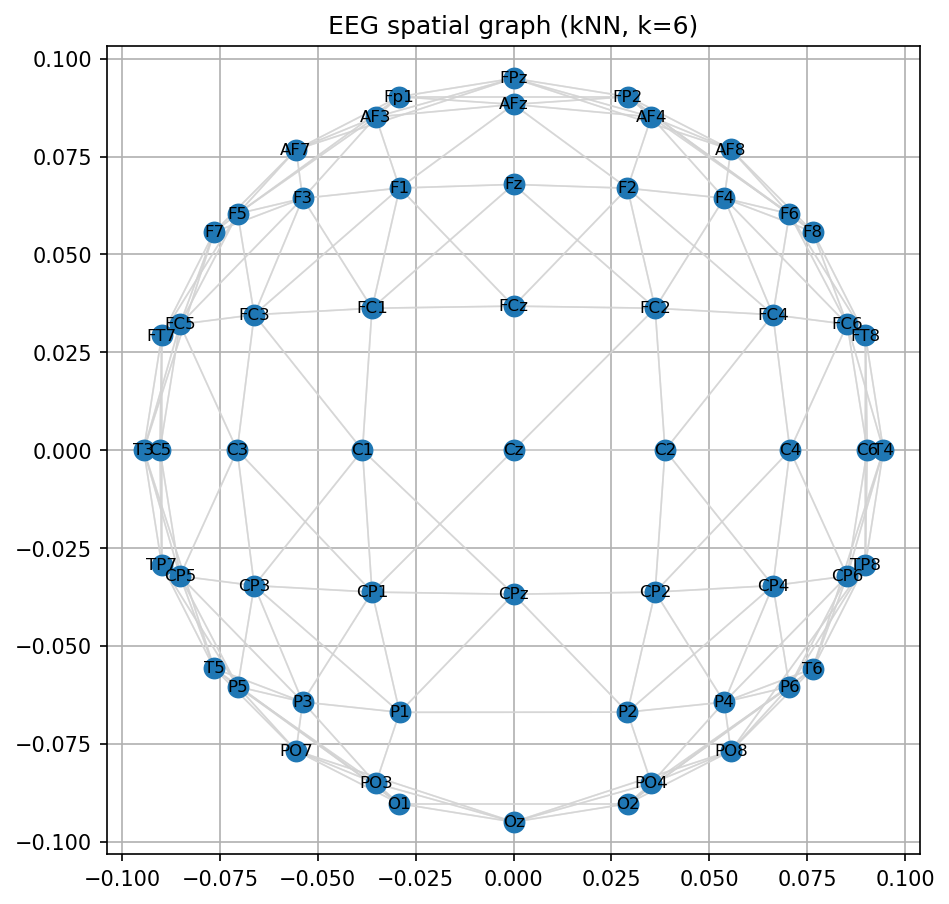

In [24]:
xy = coords[:, :2]
ei = edge_index.numpy()

plt.figure(figsize=(7, 7), dpi=150)

for s, t in ei.T:
    plt.plot(
        [xy[s, 0], xy[t, 0]],
        [xy[s, 1], xy[t, 1]],
        color="lightgray",
        linewidth=0.8,
        alpha=0.7
    )

plt.scatter(xy[:, 0], xy[:, 1], s=90, zorder=3)

for i, ch in enumerate(ch_names):
    plt.text(xy[i, 0], xy[i, 1], ch, fontsize=8, ha="center", va="center")

plt.title(f"EEG spatial graph (kNN, k={K})")
plt.axis("equal")
plt.grid(True)
plt.show()


## Plot distance matrix


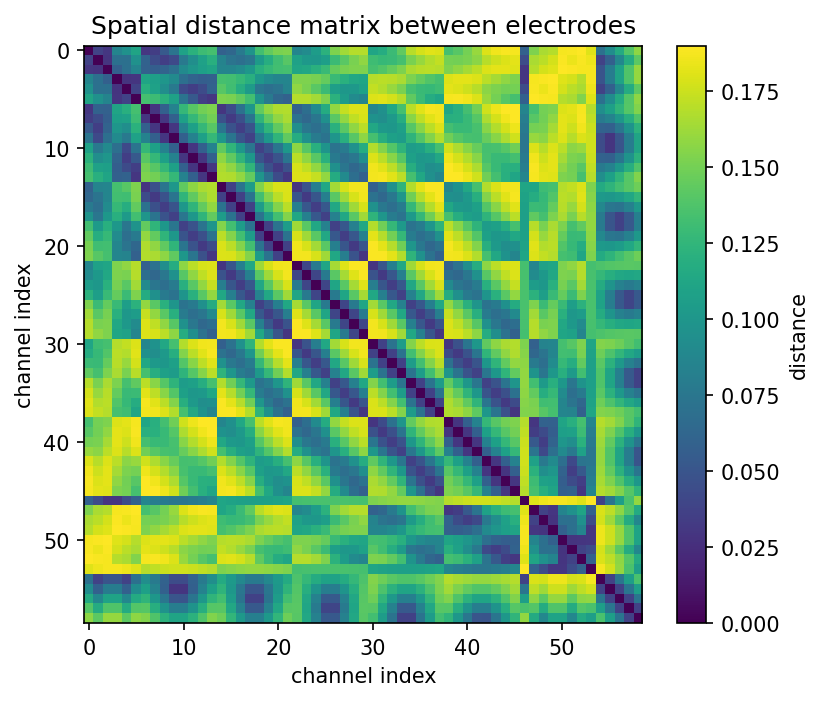

In [25]:
plt.figure(figsize=(6, 5), dpi=150)
plt.imshow(D, aspect="auto")
plt.colorbar(label="distance")
plt.title("Spatial distance matrix between electrodes")
plt.xlabel("channel index")
plt.ylabel("channel index")
plt.show()


graphs = []

for p in files:
    obj = torch.load(p, map_location="cpu")

    X = obj["X"].float()
    y = obj["y"].long()
    y = remap_y(y)
    subject_id = obj["subject_id"].long()
    session_id = obj["session_id"].long()
    epoch_idx = obj["epoch_idx"].long()

    for i in range(X.shape[0]):
        g = Data(
            x=X[i],
            edge_index=edge_index,
            y=y[i].view(1),
            subject_id=subject_id[i].view(1),
            session_id=session_id[i].view(1),
            epoch_idx=epoch_idx[i].view(1),
        )
        graphs.append(g)

print("num graphs:", len(graphs))
print(graphs[0])
print("example x shape:", graphs[0].x.shape)

In [26]:
graphs = []

for p in files:
    obj = torch.load(p, map_location="cpu")

    X = obj["X"].float()
    y = obj["y"].long()
    subject_id = obj["subject_id"].long()
    session_id = obj["session_id"].long()
    epoch_idx = obj["epoch_idx"].long()

    for i in range(X.shape[0]):
        g = Data(
            x=X[i],
            edge_index=edge_index,
            y=y[i].view(1),
            subject_id=subject_id[i].view(1),
            session_id=session_id[i].view(1),
            epoch_idx=epoch_idx[i].view(1),
        )
        graphs.append(g)

print("num graphs:", len(graphs))
print(graphs[0])
print("example x shape:", graphs[0].x.shape)


num graphs: 38926
Data(x=[59, 40], edge_index=[2, 400], y=[1], subject_id=[1], session_id=[1], epoch_idx=[1])
example x shape: torch.Size([59, 40])


## Example graph feature visualization


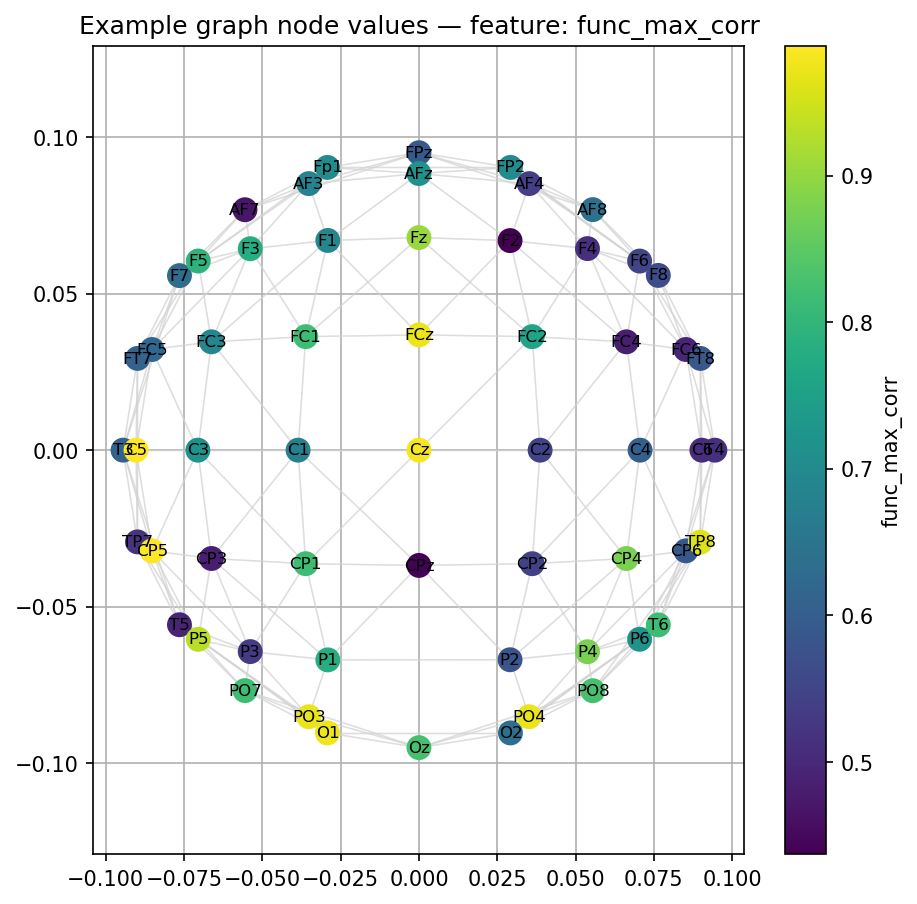

In [27]:
GRAPH_IDX = 0
FEATURE_IDX = 0

g = graphs[GRAPH_IDX]
vals = g.x[:, FEATURE_IDX].numpy()

plt.figure(figsize=(7, 7), dpi=150)

for s, t in ei.T:
    plt.plot(
        [xy[s, 0], xy[t, 0]],
        [xy[s, 1], xy[t, 1]],
        color="lightgray",
        linewidth=0.7,
        alpha=0.5
    )

sc = plt.scatter(
    xy[:, 0], xy[:, 1],
    c=vals,
    s=120,
    zorder=3
)

for i, ch in enumerate(ch_names):
    plt.text(xy[i, 0], xy[i, 1], ch, fontsize=8, ha="center", va="center")

plt.colorbar(sc, label=feature_cols[FEATURE_IDX])
plt.title(f"Example graph node values — feature: {feature_cols[FEATURE_IDX]}")
plt.axis("equal")
plt.grid(True)
plt.show()


## Split utilities


In [28]:
def get_subject_specific_split(graphs, subject_id, seed=42):
    rng = np.random.RandomState(seed)

    subj_graphs = [g for g in graphs if int(g.subject_id.item()) == subject_id]
    labels = np.array([int(g.y.item()) for g in subj_graphs])

    class_to_idx = defaultdict(list)
    for i, yy in enumerate(labels):
        class_to_idx[int(yy)].append(i)

    idx_train, idx_val, idx_test = [], [], []

    for cls, idxs in class_to_idx.items():
        idxs = np.array(idxs)
        rng.shuffle(idxs)

        if len(idxs) < 5:
            continue

        idx_train.extend(idxs[:3])
        idx_val.extend(idxs[3:4])
        idx_test.extend(idxs[4:5])

    train_graphs = [subj_graphs[i] for i in idx_train]
    val_graphs   = [subj_graphs[i] for i in idx_val]
    test_graphs  = [subj_graphs[i] for i in idx_test]

    return train_graphs, val_graphs, test_graphs


def get_subject_independent_split(graphs, test_frac=0.2, val_frac=0.2, seed=42):
    rng = np.random.RandomState(seed)

    subj_ids = sorted(list({int(g.subject_id.item()) for g in graphs}))
    rng.shuffle(subj_ids)

    n_test = max(1, int(round(len(subj_ids) * test_frac)))
    test_subjects = set(subj_ids[:n_test])

    remaining = subj_ids[n_test:]
    n_val = max(1, int(round(len(remaining) * val_frac)))
    val_subjects = set(remaining[:n_val])
    train_subjects = set(remaining[n_val:])

    train_graphs = [g for g in graphs if int(g.subject_id.item()) in train_subjects]
    val_graphs   = [g for g in graphs if int(g.subject_id.item()) in val_subjects]
    test_graphs  = [g for g in graphs if int(g.subject_id.item()) in test_subjects]

    return train_graphs, val_graphs, test_graphs, train_subjects, val_subjects, test_subjects


## GCN baseline model


In [29]:
class EEGGCN(torch.nn.Module):
    def __init__(self, in_dim=40, hidden_dim=64, n_classes=110, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin1 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.lin2 = torch.nn.Linear(hidden_dim, n_classes)
        self.dropout = dropout

    def forward(self, x, edge_index, batch, return_embedding=False):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)

        emb = x

        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        logits = self.lin2(x)

        if return_embedding:
            return logits, emb
        return logits


## Training and evaluation helpers


In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

def eval_gnn(model, loader, device="cpu"):
    model.eval()
    ys, preds = [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.batch)
            pred = logits.argmax(dim=1).cpu().numpy()
            y = batch.y.view(-1).cpu().numpy()

            preds.extend(pred.tolist())
            ys.extend(y.tolist())

    return {
        "acc": accuracy_score(ys, preds),
        "bal_acc": balanced_accuracy_score(ys, preds),
        "y_true": np.array(ys),
        "y_pred": np.array(preds),
    }


def extract_graph_embeddings(model, loader, device="cpu"):
    model.eval()
    embs, ys, subs = [], [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits, emb = model(batch.x, batch.edge_index, batch.batch, return_embedding=True)
            embs.append(emb.cpu().numpy())
            ys.append(batch.y.view(-1).cpu().numpy())
            subs.append(batch.subject_id.view(-1).cpu().numpy())

    return np.concatenate(embs), np.concatenate(ys), np.concatenate(subs)


def train_gnn(train_graphs, val_graphs, n_classes=110, hidden_dim=64, lr=1e-3, wd=1e-4,
              batch_size=64, max_epochs=100, patience=10, device="cpu"):
    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)

    model = EEGGCN(in_dim=40, hidden_dim=hidden_dim, n_classes=n_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    best_state = None
    best_val = -1.0
    history = []

    wait = 0
    for epoch in range(max_epochs):
        model.train()
        losses = []

        for batch in train_loader:
            batch = batch.to(device)

            opt.zero_grad()
            logits = model(batch.x, batch.edge_index, batch.batch)
            loss = F.cross_entropy(logits, batch.y.view(-1))
            loss.backward()
            opt.step()
            losses.append(float(loss.item()))

        val_res = eval_gnn(model, val_loader, device=device)
        mean_loss = float(np.mean(losses)) if len(losses) > 0 else np.nan
        history.append({
            "epoch": epoch + 1,
            "train_loss": mean_loss,
            "val_acc": val_res["acc"],
            "val_bal_acc": val_res["bal_acc"],
        })

        if val_res["bal_acc"] > best_val:
            best_val = val_res["bal_acc"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    history = pd.DataFrame(history)
    return model, history


device: cpu


SUBJECT_ID = 10

train_graphs, val_graphs, test_graphs = get_subject_specific_split(graphs, SUBJECT_ID, seed=42)

print("subject:", SUBJECT_ID)
print("train:", len(train_graphs))
print("val  :", len(val_graphs))
print("test :", len(test_graphs))

model_ss, hist_ss = train_gnn(
    train_graphs,
    val_graphs,
    n_classes=N_CLASSES,
    hidden_dim=64,
    lr=1e-3,
    batch_size=64,
    max_epochs=100,
    patience=10,
    device=device
)

val_loader = DataLoader(val_graphs, batch_size=64, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)

val_res_ss = eval_gnn(model_ss, val_loader, device=device)
test_res_ss = eval_gnn(model_ss, test_loader, device=device)

print("\n=== GCN | subject-specific ===")
print("val acc     :", val_res_ss["acc"])
print("val bal_acc :", val_res_ss["bal_acc"])
print("test acc    :", test_res_ss["acc"])
print("test bal_acc:", test_res_ss["bal_acc"])

In [31]:
SUBJECT_ID = 10

train_graphs, val_graphs, test_graphs = get_subject_specific_split(graphs, SUBJECT_ID, seed=42)

print("subject:", SUBJECT_ID)
print("train:", len(train_graphs))
print("val  :", len(val_graphs))
print("test :", len(test_graphs))

model_ss, hist_ss = train_gnn(
    train_graphs,
    val_graphs,
    n_classes=110,
    hidden_dim=64,
    lr=1e-3,
    batch_size=64,
    max_epochs=100,
    patience=10,
    device=device
)

val_loader = DataLoader(val_graphs, batch_size=64, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)

val_res_ss = eval_gnn(model_ss, val_loader, device=device)
test_res_ss = eval_gnn(model_ss, test_loader, device=device)

print("\n=== GCN | subject-specific ===")
print("val acc     :", val_res_ss["acc"])
print("val bal_acc :", val_res_ss["bal_acc"])
print("test acc    :", test_res_ss["acc"])
print("test bal_acc:", test_res_ss["bal_acc"])


subject: 10
train: 330
val  : 110
test : 110

=== GCN | subject-specific ===
val acc     : 0.01818181818181818
val bal_acc : 0.01818181818181818
test acc    : 0.00909090909090909
test bal_acc: 0.00909090909090909


## Plot training history — subject-specific


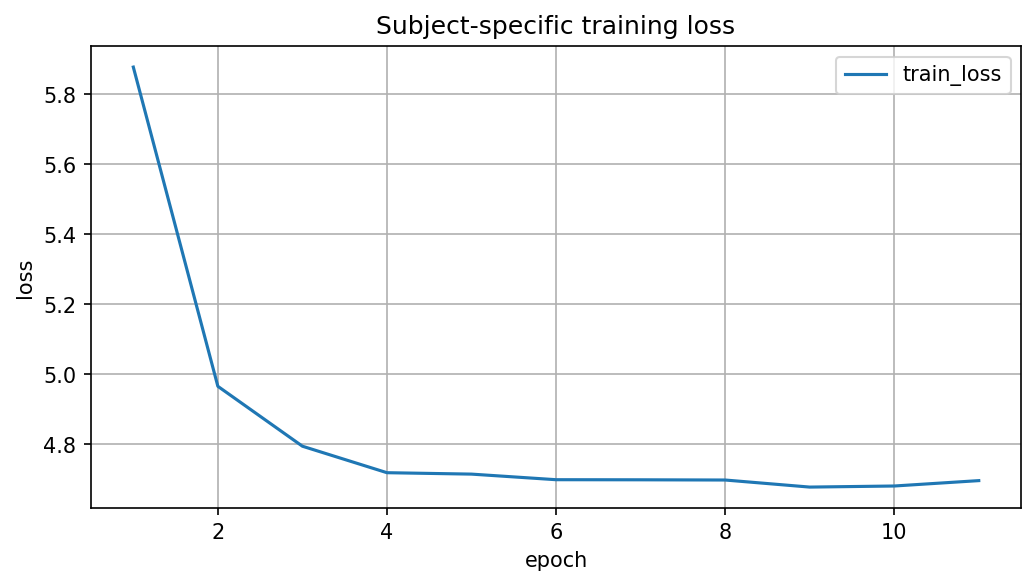

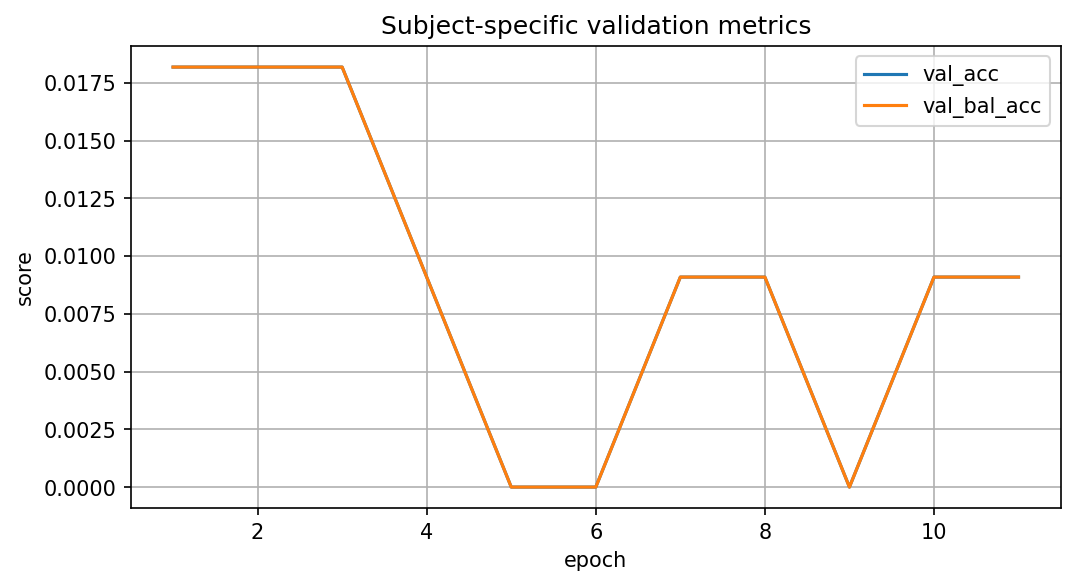

In [32]:
plt.figure(figsize=(8,4), dpi=150)
plt.plot(hist_ss["epoch"], hist_ss["train_loss"], label="train_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Subject-specific training loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,4), dpi=150)
plt.plot(hist_ss["epoch"], hist_ss["val_acc"], label="val_acc")
plt.plot(hist_ss["epoch"], hist_ss["val_bal_acc"], label="val_bal_acc")
plt.xlabel("epoch")
plt.ylabel("score")
plt.title("Subject-specific validation metrics")
plt.grid(True)
plt.legend()
plt.show()


cm = confusion_matrix(test_res_ss["y_true"], test_res_ss["y_pred"], labels=np.arange(N_CLASSES))

plt.figure(figsize=(7,6), dpi=150)
plt.imshow(cm, aspect="auto")
plt.colorbar(label="count")
plt.title("Confusion matrix — subject-specific")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.show()

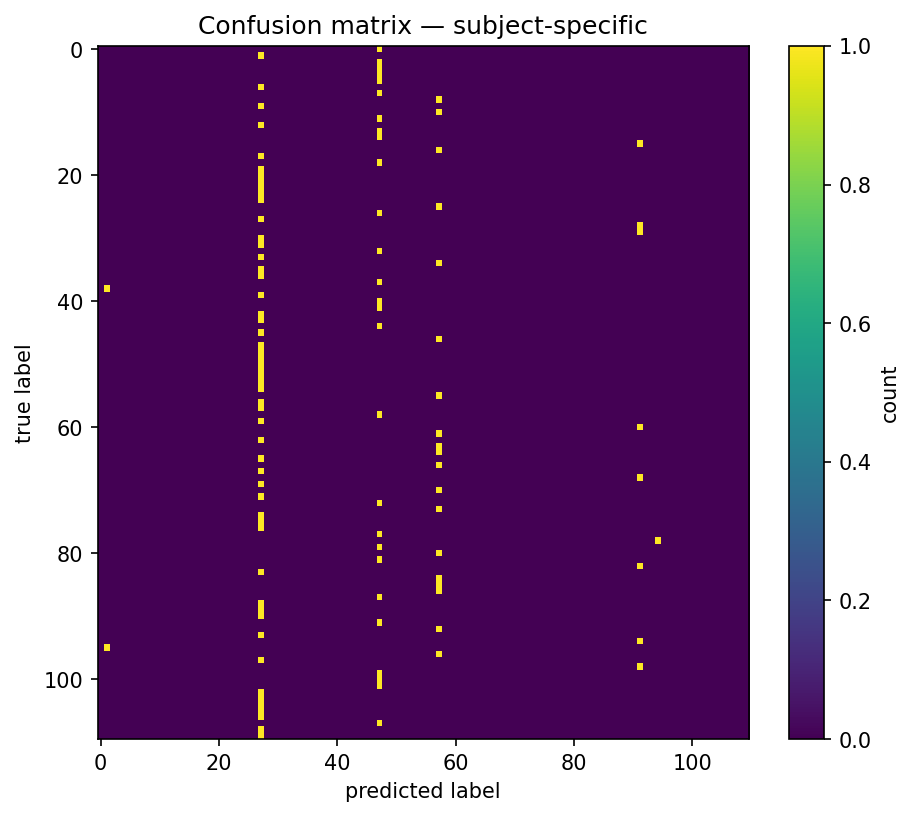

In [33]:
cm = confusion_matrix(test_res_ss["y_true"], test_res_ss["y_pred"], labels=np.arange(110))

plt.figure(figsize=(7,6), dpi=150)
plt.imshow(cm, aspect="auto")
plt.colorbar(label="count")
plt.title("Confusion matrix — subject-specific")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.show()


## Graph embeddings — subject-specific (PCA)


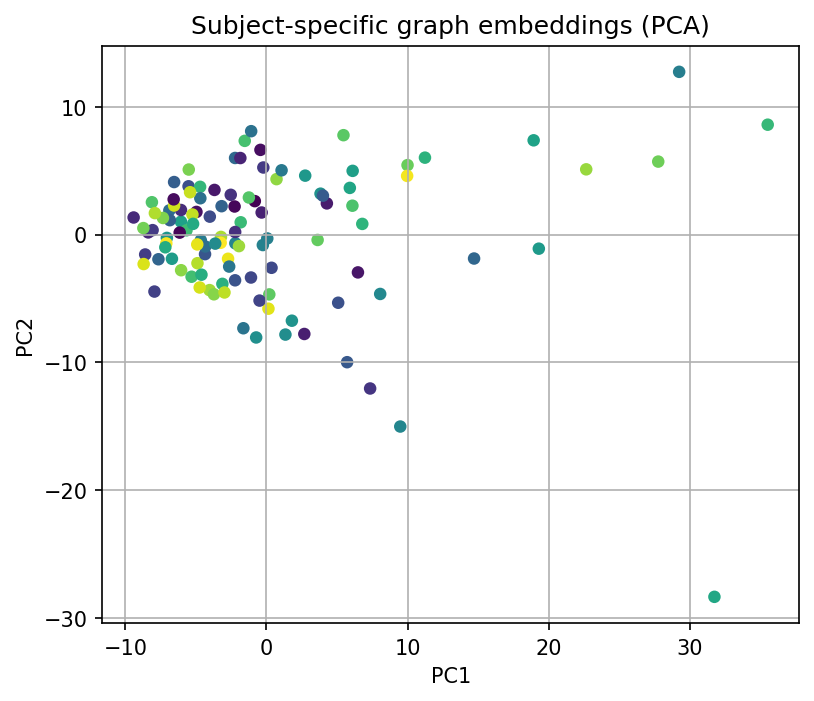

In [34]:
test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)
emb_ss, y_ss, subj_ss = extract_graph_embeddings(model_ss, test_loader, device=device)

if emb_ss.shape[0] >= 2:
    X_pca = PCA(n_components=2).fit_transform(emb_ss)

    plt.figure(figsize=(6,5), dpi=150)
    plt.scatter(X_pca[:,0], X_pca[:,1], c=y_ss, s=25)
    plt.title("Subject-specific graph embeddings (PCA)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()
else:
    print("Not enough points for PCA")


train_graphs, val_graphs, test_graphs, tr_subj, va_subj, te_subj = get_subject_independent_split(
    graphs, test_frac=0.2, val_frac=0.2, seed=42
)

print("train subjects:", len(tr_subj))
print("val subjects  :", len(va_subj))
print("test subjects :", len(te_subj))
print("train graphs  :", len(train_graphs))
print("val graphs    :", len(val_graphs))
print("test graphs   :", len(test_graphs))

model_si, hist_si = train_gnn(
    train_graphs,
    val_graphs,
    n_classes=N_CLASSES,
    hidden_dim=64,
    lr=1e-3,
    batch_size=128,
    max_epochs=100,
    patience=10,
    device=device
)

val_loader = DataLoader(val_graphs, batch_size=128, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=128, shuffle=False)

val_res_si = eval_gnn(model_si, val_loader, device=device)
test_res_si = eval_gnn(model_si, test_loader, device=device)

print("\n=== GCN | subject-independent ===")
print("val acc     :", val_res_si["acc"])
print("val bal_acc :", val_res_si["bal_acc"])
print("test acc    :", test_res_si["acc"])
print("test bal_acc:", test_res_si["bal_acc"])

In [35]:
train_graphs, val_graphs, test_graphs, tr_subj, va_subj, te_subj = get_subject_independent_split(
    graphs, test_frac=0.2, val_frac=0.2, seed=42
)

print("train subjects:", len(tr_subj))
print("val subjects  :", len(va_subj))
print("test subjects :", len(te_subj))
print("train graphs  :", len(train_graphs))
print("val graphs    :", len(val_graphs))
print("test graphs   :", len(test_graphs))

model_si, hist_si = train_gnn(
    train_graphs,
    val_graphs,
    n_classes=110,
    hidden_dim=64,
    lr=1e-3,
    batch_size=128,
    max_epochs=100,
    patience=10,
    device=device
)

val_loader = DataLoader(val_graphs, batch_size=128, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=128, shuffle=False)

val_res_si = eval_gnn(model_si, val_loader, device=device)
test_res_si = eval_gnn(model_si, test_loader, device=device)

print("\n=== GCN | subject-independent ===")
print("val acc     :", val_res_si["acc"])
print("val bal_acc :", val_res_si["bal_acc"])
print("test acc    :", test_res_si["acc"])
print("test bal_acc:", test_res_si["bal_acc"])


train subjects: 47
val subjects  : 12
test subjects : 15
train graphs  : 24900
val graphs    : 6490
test graphs   : 7536

=== GCN | subject-independent ===
val acc     : 0.00909090909090909
val bal_acc : 0.00909090909090909
test acc    : 0.009156050955414012
test bal_acc: 0.00909090909090909


## Plot training history — subject-independent


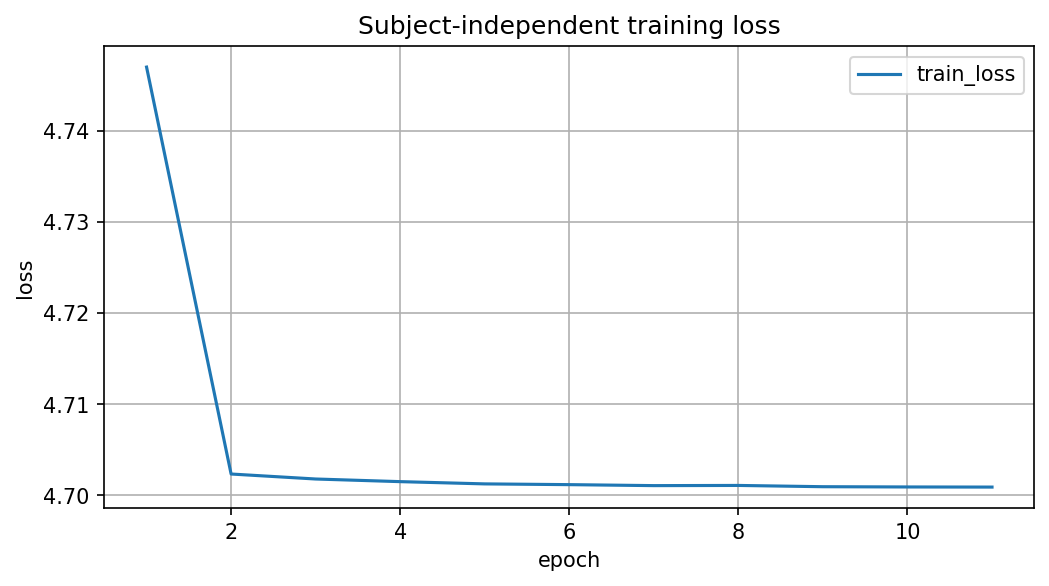

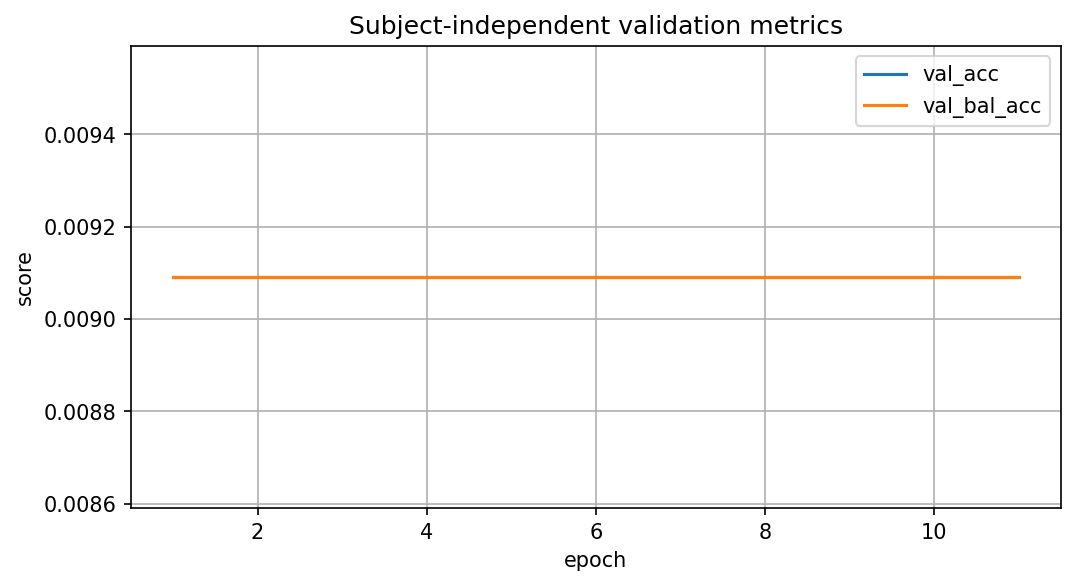

In [36]:
plt.figure(figsize=(8,4), dpi=150)
plt.plot(hist_si["epoch"], hist_si["train_loss"], label="train_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Subject-independent training loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,4), dpi=150)
plt.plot(hist_si["epoch"], hist_si["val_acc"], label="val_acc")
plt.plot(hist_si["epoch"], hist_si["val_bal_acc"], label="val_bal_acc")
plt.xlabel("epoch")
plt.ylabel("score")
plt.title("Subject-independent validation metrics")
plt.grid(True)
plt.legend()
plt.show()


## Graph embeddings — subject-independent (PCA)


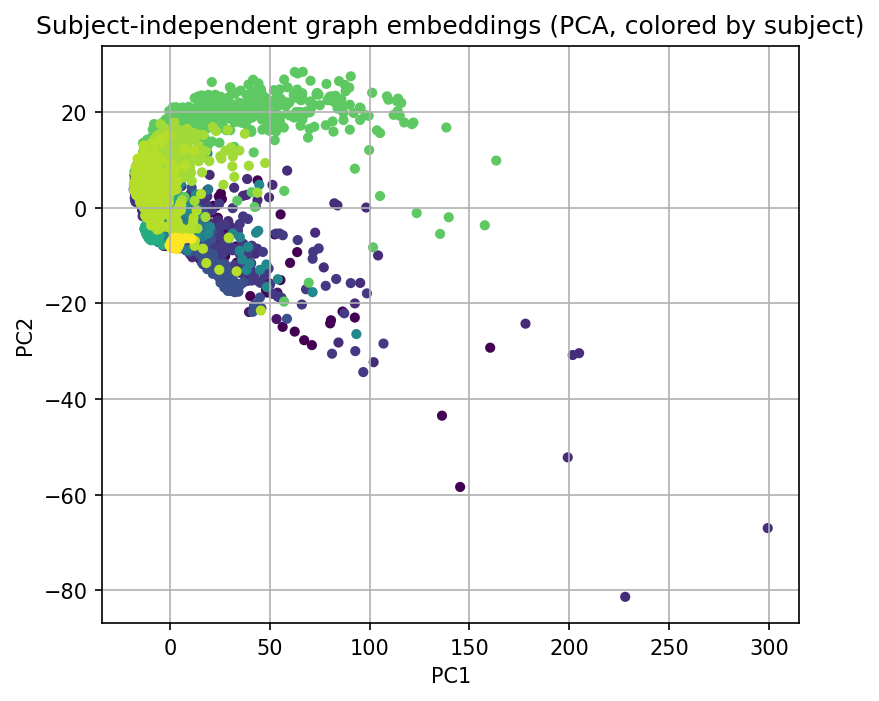

In [37]:
test_loader = DataLoader(test_graphs, batch_size=128, shuffle=False)
emb_si, y_si, subj_si = extract_graph_embeddings(model_si, test_loader, device=device)

if emb_si.shape[0] >= 2:
    X_pca = PCA(n_components=2).fit_transform(emb_si)

    plt.figure(figsize=(6,5), dpi=150)
    plt.scatter(X_pca[:,0], X_pca[:,1], c=subj_si, s=15)
    plt.title("Subject-independent graph embeddings (PCA, colored by subject)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()
else:
    print("Not enough points for PCA")


seeds = [0, 1, 2, 3, 4]
accs, baccs = [], []

for seed in seeds:
    train_graphs, val_graphs, test_graphs, *_ = get_subject_independent_split(
        graphs, test_frac=0.2, val_frac=0.2, seed=seed
    )

    model_tmp, hist_tmp = train_gnn(
        train_graphs,
        val_graphs,
        n_classes=N_CLASSES,
        hidden_dim=64,
        lr=1e-3,
        batch_size=128,
        max_epochs=100,
        patience=10,
        device=device
    )

    test_loader = DataLoader(test_graphs, batch_size=128, shuffle=False)
    res = eval_gnn(model_tmp, test_loader, device=device)

    accs.append(res["acc"])
    baccs.append(res["bal_acc"])
    print(f"seed={seed} | acc={res['acc']:.4f} | bal_acc={res['bal_acc']:.4f}")

print("\n=== GCN subject-independent summary ===")
print("acc    :", np.mean(accs), "±", np.std(accs))
print("bal_acc:", np.mean(baccs), "±", np.std(baccs))

In [ ]:
seeds = [0, 1, 2, 3, 4]
accs, baccs = [], []

for seed in seeds:
    train_graphs, val_graphs, test_graphs, *_ = get_subject_independent_split(
        graphs, test_frac=0.2, val_frac=0.2, seed=seed
    )

    model_tmp, hist_tmp = train_gnn(
        train_graphs,
        val_graphs,
        n_classes=110,
        hidden_dim=64,
        lr=1e-3,
        batch_size=128,
        max_epochs=100,
        patience=10,
        device=device
    )

    test_loader = DataLoader(test_graphs, batch_size=128, shuffle=False)
    res = eval_gnn(model_tmp, test_loader, device=device)

    accs.append(res["acc"])
    baccs.append(res["bal_acc"])
    print(f"seed={seed} | acc={res['acc']:.4f} | bal_acc={res['bal_acc']:.4f}")

print("\n=== GCN subject-independent summary ===")
print("acc    :", np.mean(accs), "±", np.std(accs))
print("bal_acc:", np.mean(baccs), "±", np.std(baccs))


seed=0 | acc=0.0093 | bal_acc=0.0091


KeyboardInterrupt: 